In [ ]:
import os
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from transformers import XLMRobertaTokenizerFast, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

Using Device: cuda


In [ ]:
TEST_DATA_PATH = "../data/processed/test.csv"
MODELS = {
    "Model 1 (Baseline)": "../models/afro-xlmr-best/afro-xlmr-best",
    "Model 2 (Weighted)": "../models/MyDrive",
}
LABEL_NAMES = ["Positive", "Neutral", "Negative"]

df_test = pd.read_csv("test.csv")
text = df_test["tweet"].astype(str).tolist()
label = df_test["label"]

def evaluate_models(model, text, label):
  print(f"Evaluating model: {model}")
  tokenizer = XLMRobertaTokenizerFast.from_pretrained(model)
  model = AutoModelForSequenceClassification.from_pretrained(model).to(device)
  model.to(device)
  model.eval()

  start_time = time.time()
  preds = []
  with torch.no_grad():
    chunks = [text[i:i + 50] for i in range(0, len(text), 50)]
    for chunk in chunks:
      inputs = tokenizer(chunk, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
      outputs = model(**inputs)
      pred_class = torch.argmax(outputs.logits, dim=-1).tolist()
      preds.extend(pred_class)
  total_time = time.time() - start_time
  average_latency = (total_time / len(text)) * 1000
  print(f"Average Latency: {average_latency:.2f} ms")

  precision, recall, f1, _ = precision_recall_fscore_support(label, preds, average="macro")
  acc = accuracy_score(label, preds)

  metrics = {"Accuracy": acc,"Macro F1":f1, "Macro Precision": precision, "Macro Recall": recall, "Average Latency": average_latency}
  return metrics, preds






Evaluating Model 1 (Baseline)...
Evaluating model: ../models/afro-xlmr-best/afro-xlmr-best


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Average Latency: 3.37 ms

CLASSIFICATION REPORT: Model 1 (Baseline)
              precision    recall  f1-score   support

     Neutral     0.5878    0.6636    0.6234       434
    Positive     0.2750    0.1429    0.1880        77
    Negative     0.7791    0.7602    0.7695       784

    accuracy                         0.6911      1295
   macro avg     0.5473    0.5222    0.5270      1295
weighted avg     0.6850    0.6911    0.6860      1295

Evaluating Model 2 (Weighted)...
Evaluating model: ../models/MyDrive


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Average Latency: 3.44 ms

CLASSIFICATION REPORT: Model 2 (Weighted)
              precision    recall  f1-score   support

     Neutral     0.6118    0.6682    0.6388       434
    Positive     0.2738    0.2987    0.2857        77
    Negative     0.8060    0.7577    0.7811       784

    accuracy                         0.7004      1295
   macro avg     0.5639    0.5749    0.5685      1295
weighted avg     0.7093    0.7004    0.7039      1295


            MODEL COMPARISON BENCHMARK


,Accuracy,Macro F1,Macro Precision,Macro Recall,Average Latency
Model 1 (Baseline),0.691120,0.526980,0.547280,0.522219,3.374036
Model 2 (Weighted),0.700386,0.568515,0.563865,0.574852,3.444863


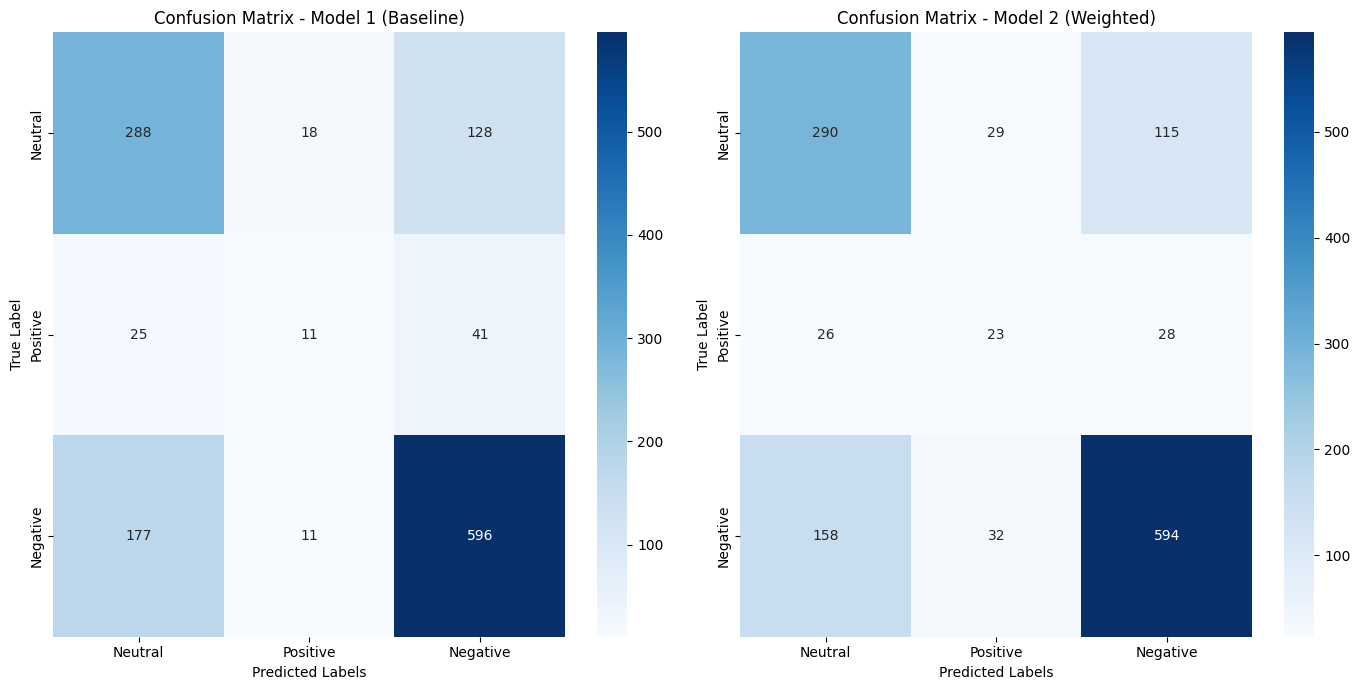

In [ ]:
results= {}
predictions = {}

for name, path in MODELS.items():
  print(f"Evaluating {name}...")
  metrics,preds = evaluate_models(path, text,label)
  results[name] = metrics
  predictions[name] = preds

  print("\n" + "=" * 55)
  print(f"CLASSIFICATION REPORT: {name}")
  print("=" * 55)
  print(
        classification_report(
            label, preds, target_names=LABEL_NAMES, digits=4
        )
    )

comparison_df = pd.DataFrame(results).T
print("\n" + "=" * 55)
print("            MODEL COMPARISON BENCHMARK")
print("=" * 55)
display(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for idx, (name,preds) in enumerate(predictions.items()):
  cm= confusion_matrix(label,preds)
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[idx])
  axes[idx].set_title(f"Confusion Matrix - {name}")
  axes[idx].set_xlabel("Predicted Labels")
  axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()